<img src="recursos/logo_UTN.svg" align="right" width="150" /> 

#### Teoría de Circuitos II

# Tarea Semanal 3

Docentes: *LLAMEDO SORIA, Mariano* y *MOHAROS, David*

Autor: *MARCHESI, Matías Sebastián*


## Introducción

En esta tarea se busca obtener, partiendo de una plantilla propuesta por los docentes, la transferencia, usando el método de aproximación de Chebyshev.

Una vez obtenida la transferencia del filtro pasabajos, se aplicará el núcleo de transformación para obtener la transferencia del filtro pasaaltos.

Con eso se obtendrá la respuesta en frecuencia cualitativamente y su diagrama de polos y ceros. Ambas cosas se compararán con lo simulado en Python.

Luego de eso se armará el circuito usando:
1. Estructuras pasivas
2. Reemplazando inductores por la estructura de GIC de Antouniou
3. Reemplazando la SOS por un MFB pasaaltos.

Para el último caso se hará un estudio de sensibilidad.

Finalmente, se verificará el cumplimiento de la plantilla mediante simulaciones de LTSPice.

## Obtención de la transferencia mediante aproximación de Chebyshev

Comienzo por usar la plantilla pasabajos dada en la consigna:

<div style="text-align: center;">
  <img src="recursos/plantillaLPF.png" width="600">
</div>

Y normalizo la frecuencia a una norma de frecuencia $\Omega_\omega = fp = 1$, entonces $fs = \frac{1}{4}$.

A eso le aplico el núcleo de transformación $f(\Omega)$ con $\Omega = \frac{1}{\omega}$ para llevarlo a una plantilla de pasaaltos.

<div style="text-align: center;">
  <img src="recursos/plantillaHPF.png" width="450">
</div>

Con eso me queda $\omega_p = 1$ y $\omega_s = 4$ porque tengo que invertir las frecuencias siguiendo con la función de transformación.

Ahora, puedo calcular los parámetros definidos por la aproximación de Chebyshev.

$$\epsilon^2 = 10^{\frac{\alpha_max}{10}} - 1$$
Y a su vez, iteraré el orden del filtro que necesito para cumplir con los requerimientos de la aproximación siguiendo la siguiente fórmula:

$$\alpha_n = 10log(1 + \epsilon^2.cosh^2(n.cosh^{-1}(\omega_s)))$$

Ambos valores serán simulados con un script de Python para más simpleza.

In [12]:
import numpy as np

# Datos de la consigna
alpha_min = 30   # dB
alpha_max = 0.5    # dB (ejemplo)
omega_s = 4        # frecuencia normalizada (ejemplo)

# Cálculo de epsilon
epsilon = np.sqrt(10**(alpha_max / 10) - 1)

# Búsqueda del primer n que cumple
n = 1

while True:
    alpha_n = 10 * np.log10(
        1 + epsilon**2 * np.cosh(n * np.arccosh(omega_s))**2
    )

    if alpha_n >= alpha_min:
        break

    n += 1

print(f"Epsilon^2 = {epsilon**2:.6f}")
print(f"Primer n que cumple: {n}")
print(f"Alpha(n) = {alpha_n:.2f} dB")

Epsilon^2 = 0.122018
Primer n que cumple: 3
Alpha(n) = 38.61 dB


Gracias a eso sé que $n=3$.

Aplico ahora la transferencia usando la aproximación por Chebyshev.

$$\large |Tn(j\omega)|^2 = \frac{1}{1 + \epsilon^2 . C_n^2(\omega)}$$

Como $n=3$, $C_3(w) = 4\omega^3 - 3\omega$.
Reemplazando:

$$\large |T(j\omega)|^2 = \frac{1}{1 + \epsilon^2 . (4\omega^3 - 3\omega)^2}$$

$$\large |T(j\omega)|^2 = \frac{1}{1 + \omega^6 . 16 . \epsilon^2 - \omega^4 .24.\epsilon^2 + \omega^2.9.\epsilon^2}$$

Reemplazando $\omega = \frac{s}{j}$ para llevarlo al rango de $s$.

$$|T(s)|^2 = \frac{1}{1 - s^6.16.\epsilon^2 - s^4.24.\epsilon^2 - s^2.9.\epsilon^2}$$

$${\color{red}(1)} \large |T(s)|^2 = \frac{\frac{1}{16.\epsilon^2}}{-s^6 - s^4. \frac{3}{2} - s^2.\frac{9}{12} + \frac{1}{16.\epsilon^2}} = T(s).T(-s)$$

$T(s). T(-s)$ se puede pensar como dos transferencias de tercer orden donde lo que cambian son los signos de los términos impares, quedando de la siguiente manera:

$$T(s).T(-s) = \frac{A}{s^3 + B.s^2 + c.s + A} . \frac{A}{-s^3 + B.s^2 - c.s + A}$$

Resolviendo se llega a:
$${\color{red}(2)} T(s).T(-s) = \frac{A^2}{-s^6 + s^4.(B^2 - 2.C) + s^2.(2.A.B - C^2) + A^2}$$

Igualando ${\color{red}(2)}$ con ${\color{red}(1)}$ se obtiene un sistema de ecuaciones:

$${\color{green}(1)} A = \frac{1}{4.\epsilon}$$

$${\color{green}(2)} \frac{3}{2} = -B^2 + 2.C$$

$${\color{green}(3)} -\frac{9}{16} = \frac{1}{2.\epsilon}.B - C^2$$

Resolviendo, despejo los coeficientes:

$$A = 0.715695$$

$$B = 1.252906$$

$$C = 1.534887$$

Dejando finalmente la $T(s)$ que se renombrará a $T_{LP}(s)$ para más claridad:

<div style="text-align:center;"">
    <div style="border: 2px solid #555; padding: 5px; border-radius: 8px; text-align: center; background-color: #f9f9f9; display: inline-block;">
        $$T_{LP}(s) = \frac{0.715695}{s^3 + s^2 . 1.252906 + s . 1.534887 + 0.715695}$$
    </div>
</div>

A su vez, se comprueba lo obtenido con un script de python mostrado a continuación:


In [13]:
import numpy as np
from scipy import signal
from pytc2.sistemas_lineales import pretty_print_lti

# DATOS
n = 3           # orden
rp = 0.5        # ripple en dB

# CHEBYSHEV LP NORMALIZADO
b_lp, a_lp = signal.cheby1(
    N=n,
    rp=rp,
    Wn=1,
    btype='low',
    analog=True,
    output='ba'
)

pretty_print_lti(b_lp,a_lp)

<IPython.core.display.Math object>

Validando lo calculado analíticamente, solo que con mayor precisión decimal en el caso de lo realizado a mano.

## Aplicando el Núcleo de Transformación (LPF $\rightarrow$ HPF)

Para pasar de la transferencia de un filtro pasabajos a la de un filtro pasaaltos debo aplicar el núcleo de transformación.

Recordando la plantilla del HPF:

<div style="text-align: center;">
  <img src="recursos/plantillaHPF.png" width="450">
</div>

Como invertí en $\Omega$ para obtener la plantilla, para obtener la transferencia hago lo mismo en $s$. La única diferencia es que renombraré la $s$ usada para la $T_{LP}$ para no confundir, usaré la siguiente simbología: $\$$

Por lo que mi núcleo sería $\$ = \large \frac{1}{s}$

Aplicándolo en la ahora llamada $T_{LP}(\$)$:

$$T_{HP}(s) = T_{LP}(\$ = \frac{1}{s}) = \large \frac{0.715695}{\frac{1}{s^3} + \frac{1}{s^2}. 1.252906 + \frac{1}{s}. 1.534887 + 0.715695}$$

Resolviendo:

$$T_{HP}(s) = \large \frac{s^3}{s^3 + s^2. 2.144625 + s. 1.75063 + 1.39725}$$

Lo voy a dejar expresado como dos transferencias, siendo una de primer orden y otra de segundo orden.

Para el caso de la transferencia de segundo orden se usa lo visto ya en otras tareas con respecto a los polos complejos conjugados. El denominador quedará expresado como:

$$D(s) = s^2 + s. | 2 .\operatorname{Re}{P} | + |P|^2$$

El coeficiente de s lo dejo expresado en módulo porque como los polos están en el semiplano izquierdo debe ser positivo ese término.

Resolviendo se obtiene:

$$
\begin{aligned}
T_{HP}(s)
&=
{\color{red}\underbrace{\color{black}\frac{s}{s + 1.596279}}_{T_1(s)}}
\cdot
{\color{red}\underbrace{\color{black}\frac{s^2}{s^2 + 0.548346\,s + 0.875517}}_{T_2(s)}}
\end{aligned}
$$

Se comprueba lo obtenido nuevamente con un script de Python:

In [14]:
import numpy as np
from scipy import signal
from pytc2.sistemas_lineales import pretty_print_lti

# DATOS
n = 3
rp = 0.5
# LP
b_lp, a_lp = signal.cheby1(
    N=n,
    rp=rp,
    Wn=1,
    btype='low',
    analog=True,
    output='ba'
)

# LP -> HP
b_hp, a_hp = signal.lp2hp(
    b_lp,
    a_lp,
    wo=1
)

sos = signal.tf2sos(b_hp, a_hp)

sec1 = sos[0]
b0, b1, b2, a0, a1, a2 = sec1
num1 = [1,0]
den1 = [a0, a1]

sec2 = sos[1]

b0, b1, b2, a0, a1, a2 = sec2

num2 = [b0, b1, b2]
den2 = [a0, a1, a2]

print("\nT1(s)")
pretty_print_lti(num1, den1)

print("\nT2(s)")
pretty_print_lti(num2, den2)


T1(s)


<IPython.core.display.Math object>


T2(s)


<IPython.core.display.Math object>

## Respuesta en frecuencia cualitativa

El módulo deberá tener una pendiente de $60dB/dec$ ya que es de orden 3, o sea, tiene 3 polos.

En $\omega = 0$ debería empezar en 0 e ir tendiendo a 1 cuando $\omega \rightarrow +\infty$ sabiendo que no tiene ganancia la transferencia como se vio arriba.

Por ser de orden 3 también debería contar con 3 rebotes en la zona del ripple. Y la diferencia entre el pico más alto y el más bajo debería ser el $\alpha_{max} = 0.5dB$.

Por último, la fase debería comenzar en $\frac{3}{2}\pi$ o $270°$ por el aporte de los tres ceros en el origen. Y a su vez, como se tienen tres polos los mismos deberían dar una caída de $\frac{3}{2}\pi$ o $270°$ en $\omega_o$

Se adjunta un gráfico realizado a mano alzada haciendo lo escrito anteriormente:
<div style="text-align: center;">
  <img src="recursos/cheby_HPF_modulo_y_fase.png" width="350">
</div>

## Comparación de diagramas de polos y ceros

Para la comparación del diagrama de polos y ceros del LPF y del HPF se usará directamente un script de Python que lo exprese en un único gráfico.

Lo que debería pasar, es que al aplicar el núcleo de transformación, los polos se deberían mapear como una inversión respecto del círculo de radio unitario. A su vez, aparecerán tres ceros en el origen en el caso del HPF

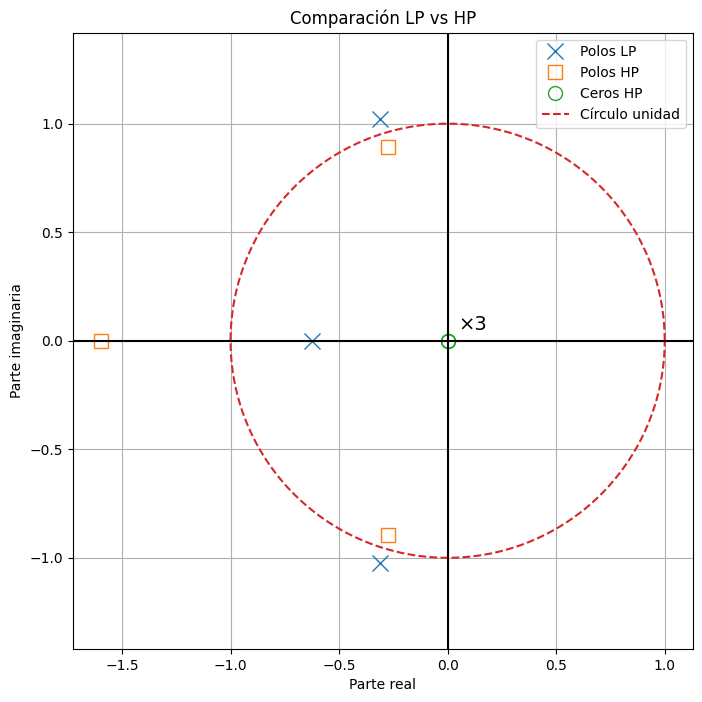

In [15]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt

# TRANSFERENCIA LP
num_lp = [0.71569]

den_lp = [1,
          1.252906,
          1.534887,
          0.71569]

# TRANSFERENCIA HP
num_hp = [1,0,0,0]

den_hp = [1,
          2.144625,
          1.75063,
          1.39725]

z_lp, p_lp, k_lp = sig.tf2zpk(num_lp, den_lp)
z_hp, p_hp, k_hp = sig.tf2zpk(num_hp, den_hp)

# Gráfico
fig, ax = plt.subplots(figsize=(8,8))

# Polos LP
ax.plot(np.real(p_lp),
        np.imag(p_lp),
        'x',
        markersize=12,
        label='Polos LP')

# Polos HP
ax.plot(np.real(p_hp),
        np.imag(p_hp),
        's',
        markersize=10,
        fillstyle='none',
        label='Polos HP')

# Ceros HP
ax.plot(np.real(z_hp),
        np.imag(z_hp),
        'o',
        markersize=10,
        fillstyle='none',
        label='Ceros HP')

ax.text(0.05,0.05,'×3',fontsize=14)

# Círculo unidad
theta = np.linspace(0,2*np.pi,500)

x = np.cos(theta)
y = np.sin(theta)

ax.plot(x,y,'--',label='Círculo unidad')

ax.axhline(0,color='black')
ax.axvline(0,color='black')
ax.grid(True)
ax.set_xlabel('Parte real')
ax.set_ylabel('Parte imaginaria')
ax.set_title('Comparación LP vs HP')
ax.legend()
ax.axis('equal')
plt.show()

## Obtención de circuitos

### Estructuras Pasivas

Para obtener el circuito con estructuras pasivas divido en dos transferencias mi $T_{HP}(s)$ y la expreso como un pasaaltos de primer orden seguido de un pasaaltos de segundo orden. 
$$T1(s) = \frac{s}{s + 1.596279}$$

$$T2(s) = \frac{s^2}{s^2 + 0.548346\,s + 0.875517}$$

Escribo ambas ecuaciones de forma genérica por su orden:
$$T1(s) = \frac{s}{s + \omega_{o1}}$$

$$T2(s) = \frac{s^2}{s^2 + s . \frac{\omega_{o2}}{Q_2} + (\omega_{o2})^2}$$

Expreso los mismos como circuitos ya conocidos:

<div style="text-align: center;">
  <img src="recursos/HPF_pasivos.png" width="450">
</div>

Divido ambas etapas con un seguidor que no impone ganancia.

De todas maneras se calculan las transferencias a partir del circuito:

$$T1(s) = \frac{s.R1.C1}{1+s.R1.C1} = \frac{s}{s+\frac{1}{R1.C1}}$$

$$T2(s) = \frac{s^2}{s^2 + s. \frac{R2}{L2} + \frac{1}{L2.C2}}$$

Comparando las ecuaciones normalizo los valores de mis componentes para obtener la respuesta deseada.

Tomo como norma de impedancia $\omega_Z = R1 = R2 = 1\Omega$

Y usando las siguientes expresiones hallo los valores de los componentes:

$$\omega_{o1} = 1.596279 = \frac{1}{R1.C1}$$

$$(\omega_{o2})^2 = 0.875517 = \frac{1}{L2.C2}$$

$$\frac{\omega_{o2}}{Q_2} = 0.548346 = \frac{R2}{L2}$$


<div style="text-align:center;"">
    <div style="border: 2px solid #555; padding: 5px; border-radius: 8px; text-align: center; background-color: #f9f9f9; display: inline-block;">
        $$C1 = 0.626457 F$$
$$R1 = 1\Omega$$
$$R2 = 1\Omega$$
$$C2 = 0.626311 F$$
$$L2 = 1.823666 Hy$$
    </div>
</div>

Se utilizan los parámetros de LTSpice para el cálculo de los componentes directamente insertando los valores de $\omega_{o1}$, $\omega_{o2}$ y $\frac{\omega_{o2}}{Q_2}$ para evitar errores de cálculos.

```.param norm_z=1```
```.param R={norm_z}```
```.param wo1=1.596279 wo2=0.935691 Q2=1.706387```
```.param C1={1/(wo1*R)}```
```.param L2={R*Q2/wo2}```
```.param C2={1/(L2*wo2*wo2)}```

<div style="text-align: center;">
  <img src="recursos/HPF_pasivos_convalores.png" width="450">
</div>

Se simula la respuesta en frecuencia con la directiva `.ac dec 10000 1u 1K` y colocando un generador como entrada de $V_i$ y obtengo:

#### Módulo

<div style="text-align: center;">
  <img src="recursos/HPF_pasivos_modulo.png" width="450">
</div>

#### Zoom en los rebotes

Se hace zoom sobre los rebotes.
<div style="text-align: center;">
  <img src="recursos/HPF_pasivos_zoom.png" width="450">
</div>

<div style="text-align: center;">
  <img src="recursos/HPF_pasivos_cursor.png" width="300">
</div>

Como se puede comprobar, la diferencia entre el rebote más alto y el más bajo es menor a $500mdB$ por lo cual, se ve que cumple con los requerimientos de la plantilla.

#### Fase

<div style="text-align: center;">
  <img src="recursos/HPF_pasivos_fase.png" width="450">
</div>

#### Retraso de grupo
<div style="text-align: center;">
  <img src="recursos/HPF_pasivos_retardo.png" width="450">
</div>


### Reemplazando inductores por GIC de Antoniu

El circuito utilizado es el siguiente:
<div style="text-align: center;">
  <img src="recursos/GIC.png" width="550">
</div>

Se puede demostrar con el desarrollo en la sección **4.5.3 llamada "The General Impedance Converter (GIC) Circuit" en el libro de Schaumann R. Van Valkenburg M E.  - Design of Analog Filters**, en la página 180 del mismo, que la inductancia equivalente, usando esta configuración del GIC, vale:

$$L_{eq} = C2.R1.R3.\frac{R5}{R4}$$

Dónde el cociente entre $R5$ y $R4$ pueden dar ganancia en la salida de $V_o$, pero en este caso, como no quiero eso simplemente igualaré todos los resistores a un valor único llamado $R$.

$$L_{eq} = C2.R^2$$

Recordando el valor del componente anteriormente llamado $L2 = 1.823666 Hy$

$$1.823666 Hy = C2 . R^2$$

Lo que haré es tomar mi norma de impedancia para este subcircuito como $\Omega_z = R = 1 \Omega$ para facilitar los cálculos.

Con eso obtengo el valor de $C2$.

$$C2 = 1.823666 F$$

Ahora, pongo esos valores en LTSpice, y usando parámetros hago los cálculos allí para evitar errores de typeo. Este GIC lo voy a intercambiar por el único inductor que tengo, y como tiene un extremo a GND el nodo que yo llamé $V_o$ no lo voy a utilizar ya que no me interesa esa salida.

A continuación se dejan los parámetros usados en LTSpice:

```.param norm_z=1```
```.param R={norm_z}```
```.param wo1=1.596279 wo2=0.935691 Q2=1.706387```
```.param C1={1/(wo1*R)}```
```.param L2={R*Q2/wo2}```
```.param C2={1/(L2*wo2*wo2)}```
```.param R_GIC={norm_z}```
```.param C2_GIC={L2*R_GIC}```

El circuito completo, reemplazando L2 por el GIC queda así:
<div style="text-align: center;">
  <img src="recursos/HPF_conGIC_convalores.png" width="550">
</div>

Se simula la respuesta en frecuencia con la directiva `.ac dec 10000 1u 1K` y colocando un generador como entrada de $V_i$ y obtengo:

#### Módulo

<div style="text-align: center;">
  <img src="recursos/HPF_conGIC_modulo.png" width="450">
</div>

#### Zoom en los rebotes
Se hace zoom sobre los rebotes.
<div style="text-align: center;">
  <img src="recursos/HPF_conGIC_zoom.png" width="450">
</div>

<div style="text-align: center;">
  <img src="recursos/HPF_conGIC_cursor.png" width="300">
</div>

Como se puede comprobar, la diferencia entre el rebote más alto y el más bajo es menor a $500mdB$ por lo cual, se ve que cumple con los requerimientos de la plantilla.

#### Fase

<div style="text-align: center;">
  <img src="recursos/HPF_conGIC_fase.png" width="450">
</div>

#### Retraso de grupo
<div style="text-align: center;">
  <img src="recursos/HPF_conGIC_retardo.png" width="450">
</div>


### Reemplazando segunda etapa por un MFB

Comienzo con una foto del circuito del MFB pasaaltos colocándole los nombres a los nodos.

<div style="text-align: center;">
  <img src="recursos/MFB_nodos.png" width="450">
</div>

Resuelvo por el método de nodos:
$${\color{red}(1)} VA.(s.C1 + s.C3 + G1 + s.C2) - VB . (s.C2) - Vi . (s.C3) - Vo . (s . C1) = 0$$

$${\color{red}(2)} V_B.(s.C2 + G2) - V_A . (s.C2) - Vo.(G2) = 0$$

$${\color{red}(3)} VB = 0$$

Reescribo ${\color{red}(2)}$ considerando lo expresado en ${\color{red}(3)}$:

$${\color{red}(2)} - V_A . (s.C2) - Vo.(G2) = 0$$

$$VA = - Vo . \frac{G2}{s.C2}$$

Reemplazando ahora en ${\color{red}(1)}$:

$$ - Vo . \frac{G2}{s.C2}.(s.C1 + s.C3 + G1 + s.C2) - Vi . (s.C3) - Vo . (s . C1) = 0$$

Multiplico ambos términos por $s.C2$:

$$ - Vo.[s^2.C1.C2 + s.(C1+C2+C3).G2 + G1.G2] = Vi . (s^2.C2.C3)$$

$$T(s) = \frac{Vo}{Vi} = - \frac{s^2 .C2.C3}{s^2.C1.C2 + s.(C1.G2 + C2.G2 + C3.G2) + G1.G2}$$

Multiplicando y dividiendo por $C1.C2$ para dejar el término de $s^2$ como unitario.

$$T(s) = \frac{Vo}{Vi} = - \frac{s^2 . \frac{C3}{C1}}{s^2 + s.(\frac{G2}{C2} + \frac{G2}{C1} + \frac{G2.C3}{C1.C2}) + \frac{G1.G2}{C1.C2}}$$

Recordando la expresión de la etapa SOS que yo llamé $T2(s)$.

$$T2(s) = \frac{s^2}{s^2 + s.0.548346 + 0.875517}$$

Ignorando el signo negativo obtenido ya que el mismo puede ser suprimido luego con una etapa inversora sin ganancia, busco que mis transferencias concuerden, el único inconveniente es el numerador, que tiene un $\frac{C3}{C1}$. La forma más sencilla de hacer que no esté ahí es hacer el cociente unitario, o hacer que ambos tengan el mismo valor $C1=C3=C$.

$$T(s) = - \frac{s^2}{s^2 + s.(2.\frac{G2}{C2} + \frac{G2}{C}) + \frac{G1.G2}{C.C2}}$$

Para sacar grados de libertad de la ecuación lo más sencillo es comenzar a sacar componentes haciéndolos valer 1. En este caso impondré como mi norma de impedancia $\Omega_z = C1 = C2 = C3 = 1$ quedando la $T(s)$:

$$T(s) = - \frac{s^2}{s^2 + s.\frac{3}{R2} + \frac{1}{R1.R2}}$$

Y resolviendo en base a la comparación de la transferencia $T2(s)$ y la $T(s)$ obtenida para este ejercicio:

$$\frac{\omega_o}{Q} = 0.548346 =\frac{3}{R2}$$

$$\omega_o^2 = 0.875517 =\frac{1}{R1.R2}$$

Obtengo los valores del circuito:

<div style="text-align:center;"">
    <div style="border: 2px solid #555; padding: 5px; border-radius: 8px; text-align: center; background-color: #f9f9f9; display: inline-block;">
        
  $$R1 = 0.20877 \Omega$$
  $$R2 = 5.490998 \Omega$$
  $$C1=1F$$
  $$C2=1F$$
  $$C3=1F$$
    </div>
</div>

Procedo a simularlo en LTSpice para comparar con lo obtenido anteriormente. Para evitar errores nuevamente utilizaré definiré los componentes como parámetros de funciones. Los params son: 
```.param norm_z = 1```
```.param R={norm_z}```
```.param wo1=1.596279 wo2=0.935691 Q2=1.706387```
```.param C1={1/wo1*R}```
```.param L2={wo2/Q2*R}```
```.param C2={1/L2*wo2*wo2}```
```.param C={norm_z}```
```.param a=0.548346 b=0.875517```
```.param R2={3/a} R1={1/(b*R2)}```

Quedando el circuito:

<div style="text-align: center;">
  <img src="recursos/HPF_conMFB_convalores.png" width="450">
</div>

Se simula la respuesta en frecuencia con la directiva `.ac dec 10000 1u 1K` y colocando un generador como entrada de $V_i$ y obtengo:

#### Módulo

<div style="text-align: center;">
  <img src="recursos/HPF_conMFB_modulo.png" width="450">
</div>

### Zoom en rebotes

Se hará un zoom en los rebotes que presenta la configuración:

<div style="text-align: center;">
  <img src="recursos/HPF_conMFB_zoom.png" width="450">
</div>

<div style="text-align: center;">
  <img src="recursos/HPF_conMFB_cursor.png" width="250">
</div>
Como se puede comprobar utilizando cursores, la diferencia entre el rebote más alto y el más bajo apenas menor a $500mdB$ por lo cual, se ve que cumple con los requerimientos de la plantilla.

#### Fase

<div style="text-align: center;">
  <img src="recursos/HPF_conGIC_fase.png" width="450">
</div>

#### Retraso de grupo
<div style="text-align: center;">
  <img src="recursos/HPF_conGIC_retardo.png" width="450">
</div>

### Estudio de Sensibilidad con el MFB

Para el estudio de sensibilidad recuerdo la expresión:

$$S_x^y = \frac{\partial{y}}{\partial{x}} . \frac{x}{y} = \frac{\partial{ln(y)}}{\partial{ln(x)}}$$

Esta expresión se obtiene en el **Capítulo 12, llamado "Sensitivity" en el libro de Schaumann R. Van Valkenburg M E.  - Design of Analog Filters, página 456**.

Recordando las expresiones obtenidas antes:

$${\color{red} (1)}\ \omega_o = \frac{1}{\sqrt{R1.R2}}$$

$$\frac{\omega_o}{Q} = \frac{3}{R2}$$

$$Q = \frac{\omega_o}{3/R2}$$

Reemplazo ${\color{red} (1)}$ en esta ecuación:

$$Q = \frac{1}{\sqrt{R1.R2}}\frac{1}{3/R2}$$

$$Q = \frac{1}{3} \sqrt{\frac{R2}{R1}}$$

Expreso $\omega_o$ y $Q$ de manera más cómoda para derivar:

$$\omega_o = (R1.R2)^{-\frac{1}{2}}$$

$$Q = \frac{1}{3}.(\frac{R2}{R1})^{\frac{1}{2}}$$

$$ln(Q) = ln(\frac{1}{3}) + \frac{1}{2}.ln(R2) - \frac{1}{2}.ln(R1)$$

<div style="text-align:center;"">
    <div style="border: 2px solid #555; padding: 5px; border-radius: 8px; text-align: center; background-color: #f9f9f9; display: inline-block;">
$$S_Q^{R1} = \frac{\partial{ln(Q)}}{\partial{ln(R1)}} = - \frac{1}{2}$$
$$S_Q^{R2} = \frac{\partial{ln(Q)}}{\partial{ln(R2)}} = + \frac{1}{2}$$
    </div>
</div>

Para hallar la sensibilidad para $C1$ tengo que volver al a expresión de $\omega_o$ antes de normalizar los valores, la misma era:

$$\omega_o = \sqrt{\frac{G1.G2}{C1.C2}}$$

Viendo rápidamente que $C1$ debería quedar:
<div style="text-align:center;"">
    <div style="border: 2px solid #555; padding: 5px; border-radius: 8px; text-align: center; background-color: #f9f9f9; display: inline-block;">
$$S_{\omega_o}^{C1} = -\frac{1}{2}$$
    </div>
</div>

Básicamente, para todos los casos la sensibilidad da $|0.5|$, lo cual es esperable, ya que la misma es un factor de calidad y cuanto menor sea mejor será mi filtro. De esta manera, un cambio del 1% en las resistencias produce variaciones de solamente 0.5% en el Q y un cambio del 1% en el capacitor produce variaciones solamente del 0.5% en el $\omega_o$.

## Análsis para aproximación de Máxima Planicidad

La misma red podría implementarse utilizando una aproximación de MP, manteniendo la misma estructura circuital. Lo que si, variarían las posiciones de los polos y el Q, por lo que deberían recalcularse los valores de los componentes. 

Para poder ver visualmente la diferencia se añade la simulación comparando los diagramas de polos y ceros del caso de MP y del caso de Chebyshev.

Se pide compromar si para la aproximación de Máxima Planicidad (MP) al mismo orden que por Chebyshev se obtiene la plantilla deseada.

La primer manera de comprobar que esto no será así es utilizando la ecuación para hallar el orden de cada caso:

$$\alpha_{chebyshev} = 10log(1 + \epsilon^2.cosh^2(n.cosh^{-1}(\omega_s)))$$

$$\alpha_{mp} = 10log(1+\epsilon^2.\omega_s^{2n})$$

Para comparar haré un pequeño script de python que itere ambas ecuaciones y llegue al n mínimo. Si pudiera replicarse en el mismo orden tendrían que coincidir en n=3.

In [16]:
import numpy as np

# Datos de la consigna
alpha_min = 30      # dB
alpha_max = 0.5     # dB
omega_s = 4

# epsilon
epsilon = np.sqrt(10**(alpha_max/10) - 1)


#Chebyshev
n_cheby = 1

while True:

    alpha_cheby = 10*np.log10(
        1 + epsilon**2 *
        np.cosh(
            n_cheby*np.arccosh(omega_s)
        )**2
    )

    if alpha_cheby >= alpha_min:
        break

    n_cheby += 1

#MP

n_mp = 1

while True:

    alpha_mp = 10*np.log10(
        1 + epsilon**2 *
        omega_s**(2*n_mp)
    )

    if alpha_mp >= alpha_min:
        break

    n_mp += 1

alpha_mp_orden_cheby = 10*np.log10(
        1 + epsilon**2 *
        omega_s**(2*n_cheby)
    )

print("Chebyshev")
print(f"n mínimo = {n_cheby}")
print(f"α(ωs) = {alpha_cheby:.2f} dB")
print()

print("Máxima Planicidad")
print(f"n mínimo = {n_mp}")
print(f"α(ωs) = {alpha_mp:.2f} dB")

print()
print("Máxima Planicidad para mismo del chebyshev")
print(f"α(ωs) = {alpha_mp_orden_cheby:.2f} dB")

Chebyshev
n mínimo = 3
α(ωs) = 38.61 dB

Máxima Planicidad
n mínimo = 4
α(ωs) = 39.03 dB

Máxima Planicidad para mismo del chebyshev
α(ωs) = 27.00 dB


Cómo indica el script el n necesario para llegar a $30dB$ de $\alpha_{min}$ es 3 para el chebyshev como se mostró en toda la tarea, y en el caso del máxima planicidad necesito más, ya que para $n=3$ obtengo 27dB, que no cumplen.

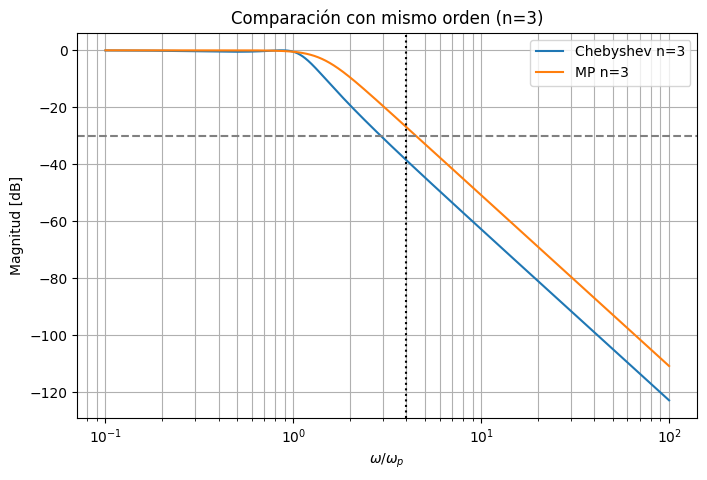

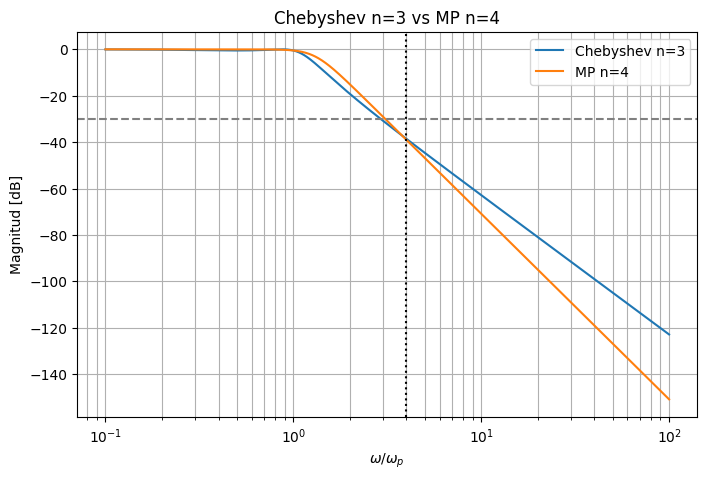

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Datos
alpha_max = 0.5
alpha_min = 30
ws = 4

epsilon = np.sqrt(10**(alpha_max/10) - 1)

w = np.logspace(-1, 2, 3000)

def H_cheby(w, n, eps):

    H = np.zeros_like(w)

    idx_pb = w <= 1
    idx_sb = w > 1

    H[idx_pb] = 1/np.sqrt(
        1 + eps**2 *
        np.cos(
            n*np.arccos(w[idx_pb])
        )**2
    )

    H[idx_sb] = 1/np.sqrt(
        1 + eps**2 *
        np.cosh(
            n*np.arccosh(w[idx_sb])
        )**2
    )

    return H


def H_mp(w, n, eps):

    return 1/np.sqrt(
        1 + eps**2 * w**(2*n)
    )

Hc3  = H_cheby(w, 3, epsilon)
Hmp3 = H_mp(w, 3, epsilon)
Hmp4 = H_mp(w, 4, epsilon)

# FIGURA 1
plt.figure(figsize=(8,5))

plt.semilogx(
    w,
    20*np.log10(Hc3),
    label='Chebyshev n=3'
)

plt.semilogx(
    w,
    20*np.log10(Hmp3),
    label='MP n=3'
)

plt.axvline(ws, color='k', linestyle=':')
plt.axhline(-alpha_min, color='gray', linestyle='--')

plt.grid(True, which='both')
plt.xlabel(r'$\omega/\omega_p$')
plt.ylabel('Magnitud [dB]')
plt.title('Comparación con mismo orden (n=3)')
plt.legend()

# FIGURA 2
plt.figure(figsize=(8,5))

plt.semilogx(
    w,
    20*np.log10(Hc3),
    label='Chebyshev n=3'
)

plt.semilogx(
    w,
    20*np.log10(Hmp4),
    label='MP n=4'
)

plt.axvline(ws, color='k', linestyle=':')
plt.axhline(-alpha_min, color='gray', linestyle='--')

plt.grid(True, which='both')
plt.xlabel(r'$\omega/\omega_p$')
plt.ylabel('Magnitud [dB]')
plt.title('Chebyshev n=3 vs MP n=4')
plt.legend()

plt.show()

Se hace un script para comparar como queda gráficamente la respuesta de cada caso. La primer figura muestra cuando uso el n=3 para ambos casos y como el chebyshev cumple y el máxima planicidad no. La segunda figura muestra como el máxima planicidad de n=4 da prácticamente igual al n=3 del cheby, como se comprueba en el script numérico de arriba.